In [1]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.4 MB/s eta 0:00:00


In [3]:
from pathlib import Path
import zipfile
import yaml
import cv2
import pandas as pd
import matplotlib.pyplot as plt

import ultralytics
from ultralytics import YOLO

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
ZIP_PATH="/content/drive/MyDrive/Smart_Warehouse_Inventory_ Project.zip"

EXTRACT_PATH="/content"

with zipfile.ZipFile(ZIP_PATH,"r") as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Project Extracted Successfully")

Project Extracted Successfully


In [7]:
PROJECT_ROOT=Path("/content/Smart_Warehouse_Inventory_ Project")

DATASET_PATH=PROJECT_ROOT/"dataset"

DATA_YAML=DATASET_PATH/"data.yaml"

MODEL_PATH=Path("/content/drive/MyDrive/YOLO_Training/warehouse_inventory/weights/best.pt")

RESULTS_FOLDER=Path("/content/drive/MyDrive/YOLO_Training/warehouse_inventory")
print(PROJECT_ROOT.exists())
print(DATASET_PATH.exists())
print(DATA_YAML.exists())
print(MODEL_PATH.exists())
print(RESULTS_FOLDER.exists())

True
True
True
True
True


In [8]:
# Load MOdel
model=YOLO(MODEL_PATH)

print("Model Loaded Successfully")

Model Loaded Successfully


In [9]:
# Validation
metrics=model.val(
    data=str(DATA_YAML)
)

print("Validation Completed Successfully")

Ultralytics 8.4.96 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,010,523 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1761.5±1027.3 MB/s, size: 370.0 KB)
val: Scanning /content/Smart_Warehouse_Inventory_ Project/dataset/labels/val... 1125 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1125/1125 939.7it/s 1.2s
val: New cache created: /content/Smart_Warehouse_Inventory_ Project/dataset/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 71/71 4.2s/it 4:56
                   all       1125      13873      0.657       0.53      0.588      0.499
                   box       1038       1038      0.692      0.662      0.701      0.593
                 crate        218        218      0.631      0.344      0.431      0.328
                barrel        206        206      0.565      0.301      0.364      0.256
            

In [11]:
# Model Evaluation

print(f"mAP@0.5        : {metrics.box.map50:.4f}")

print(f"mAP@0.5:0.95   : {metrics.box.map:.4f}")

print(f"Precision      : {metrics.box.mp:.4f}")

print(f"Recall         : {metrics.box.mr:.4f}")

mAP@0.5        : 0.5879
mAP@0.5:0.95   : 0.4988
Precision      : 0.6571
Recall         : 0.5304


In [12]:
# Read Training Results

results_csv=RESULTS_FOLDER/"results.csv"

results_df=pd.read_csv(results_csv)

results_df.head()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,116.028,1.80318,4.15590,1.64622,0.40923,0.09010,0.05822,0.04040,1.52150,3.47907,1.41438,0.000115,0.000115,0.000115
1,2,223.877,1.33308,3.04524,1.32045,0.48059,0.16088,0.12052,0.08883,1.19933,2.70278,1.19230,0.000218,0.000218,0.000218
2,3,330.604,1.13204,2.49486,1.19903,0.44807,0.20330,0.18092,0.13623,1.08587,2.39151,1.11648,0.000310,0.000310,0.000310
3,4,439.956,1.01965,2.19722,1.12709,0.45151,0.26364,0.24971,0.18990,0.95995,2.03371,1.05146,0.000294,0.000294,0.000294
4,5,549.352,0.95855,2.01342,1.08919,0.45516,0.30018,0.29603,0.23447,0.84887,1.82592,0.99880,0.000277,0.000277,0.000277


In [13]:
# Display last epoch
results_df.tail(1)

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
19,20,2134.04,0.5754,0.97786,0.91993,0.65694,0.53054,0.58798,0.4983,0.5389,0.94791,0.84208,0.000021,0.000021,0.000021


In [14]:
# Best epoch
best_epoch=results_df["metrics/mAP50(B)"].idxmax()

print("Best Epoch :",best_epoch)

print()

print(results_df.loc[best_epoch])

Best Epoch : 19

epoch                     20.000000
time                    2134.040000
train/box_loss             0.575400
train/cls_loss             0.977860
train/dfl_loss             0.919930
metrics/precision(B)       0.656940
metrics/recall(B)          0.530540
metrics/mAP50(B)           0.587980
metrics/mAP50-95(B)        0.498300
val/box_loss               0.538900
val/cls_loss               0.947910
val/dfl_loss               0.842080
lr/pg0                     0.000021
lr/pg1                     0.000021
lr/pg2                     0.000021
Name: 19, dtype: float64


In [19]:
from pathlib import Path

for file in sorted(RESULTS_FOLDER.iterdir()):
    print(file.name)



BoxF1_curve.png
BoxPR_curve.png
BoxP_curve.png
BoxR_curve.png
args.yaml
confusion_matrix.png
confusion_matrix_normalized.png
labels.jpg
results.csv
results.png
train_batch0.jpg
train_batch1.jpg
train_batch2.jpg
train_batch2910.jpg
train_batch2911.jpg
train_batch2912.jpg
val_batch0_labels.jpg
val_batch0_pred.jpg
val_batch1_labels.jpg
val_batch1_pred.jpg
val_batch2_labels.jpg
val_batch2_pred.jpg
weights


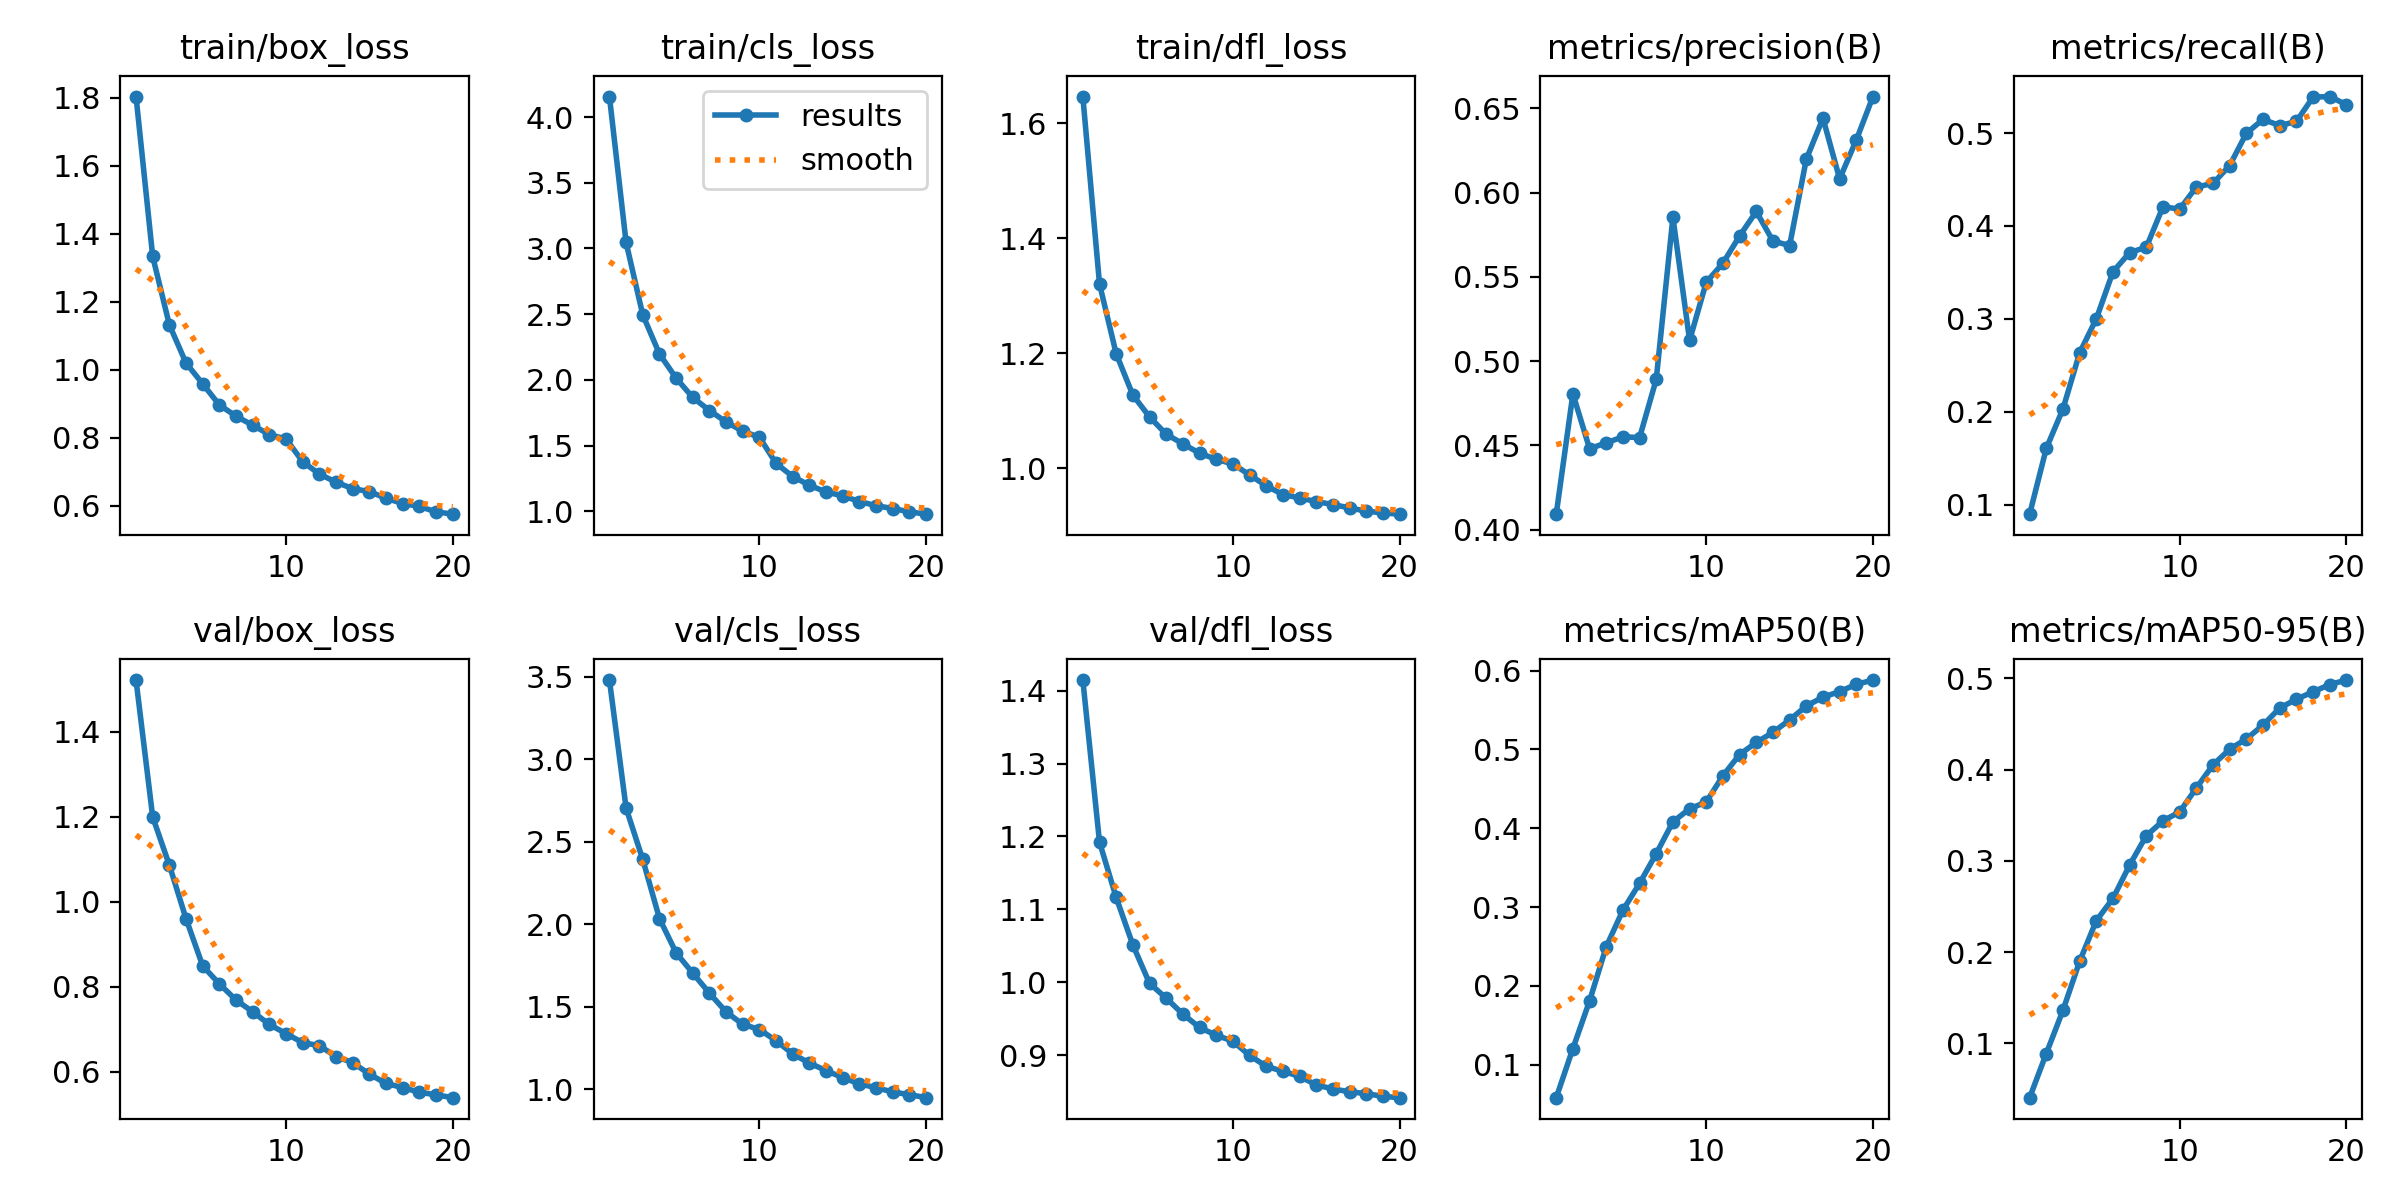

In [20]:
# Display Training Curves
from IPython.display import Image

Image(filename=str(RESULTS_FOLDER/"results.png"))

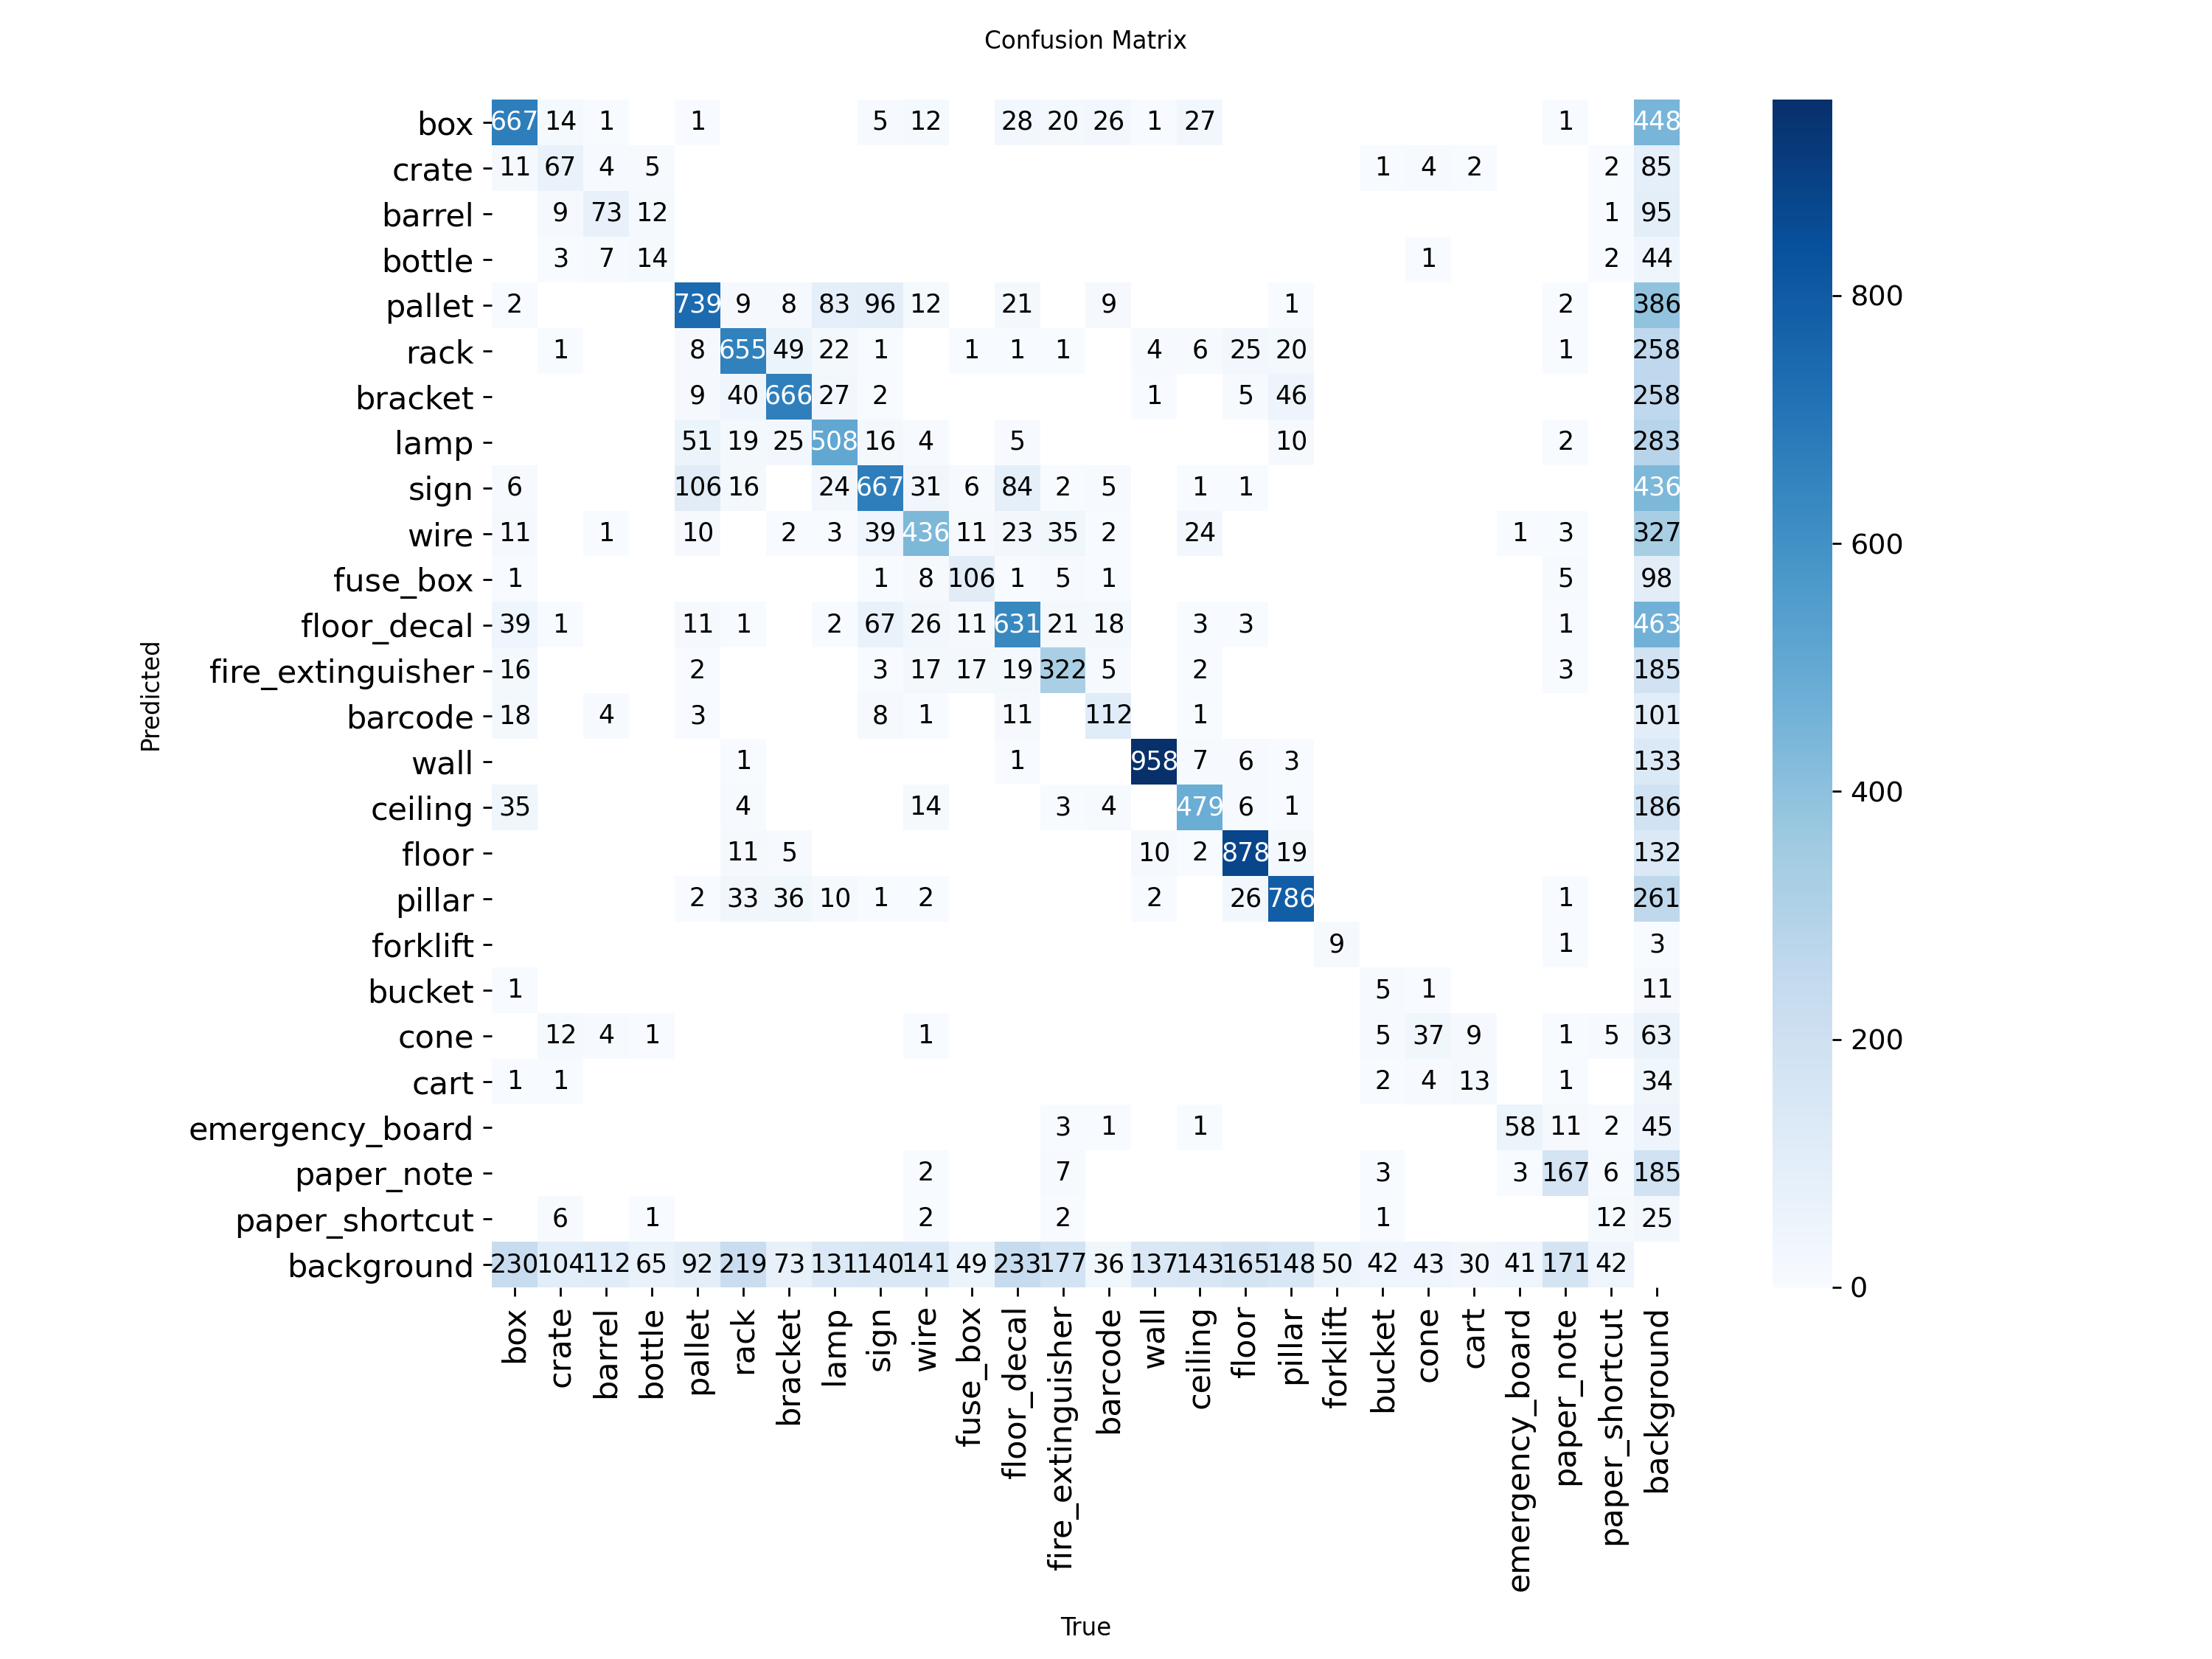

In [21]:
# Confusion Matrix

Image(filename=str(RESULTS_FOLDER/"confusion_matrix.png"))



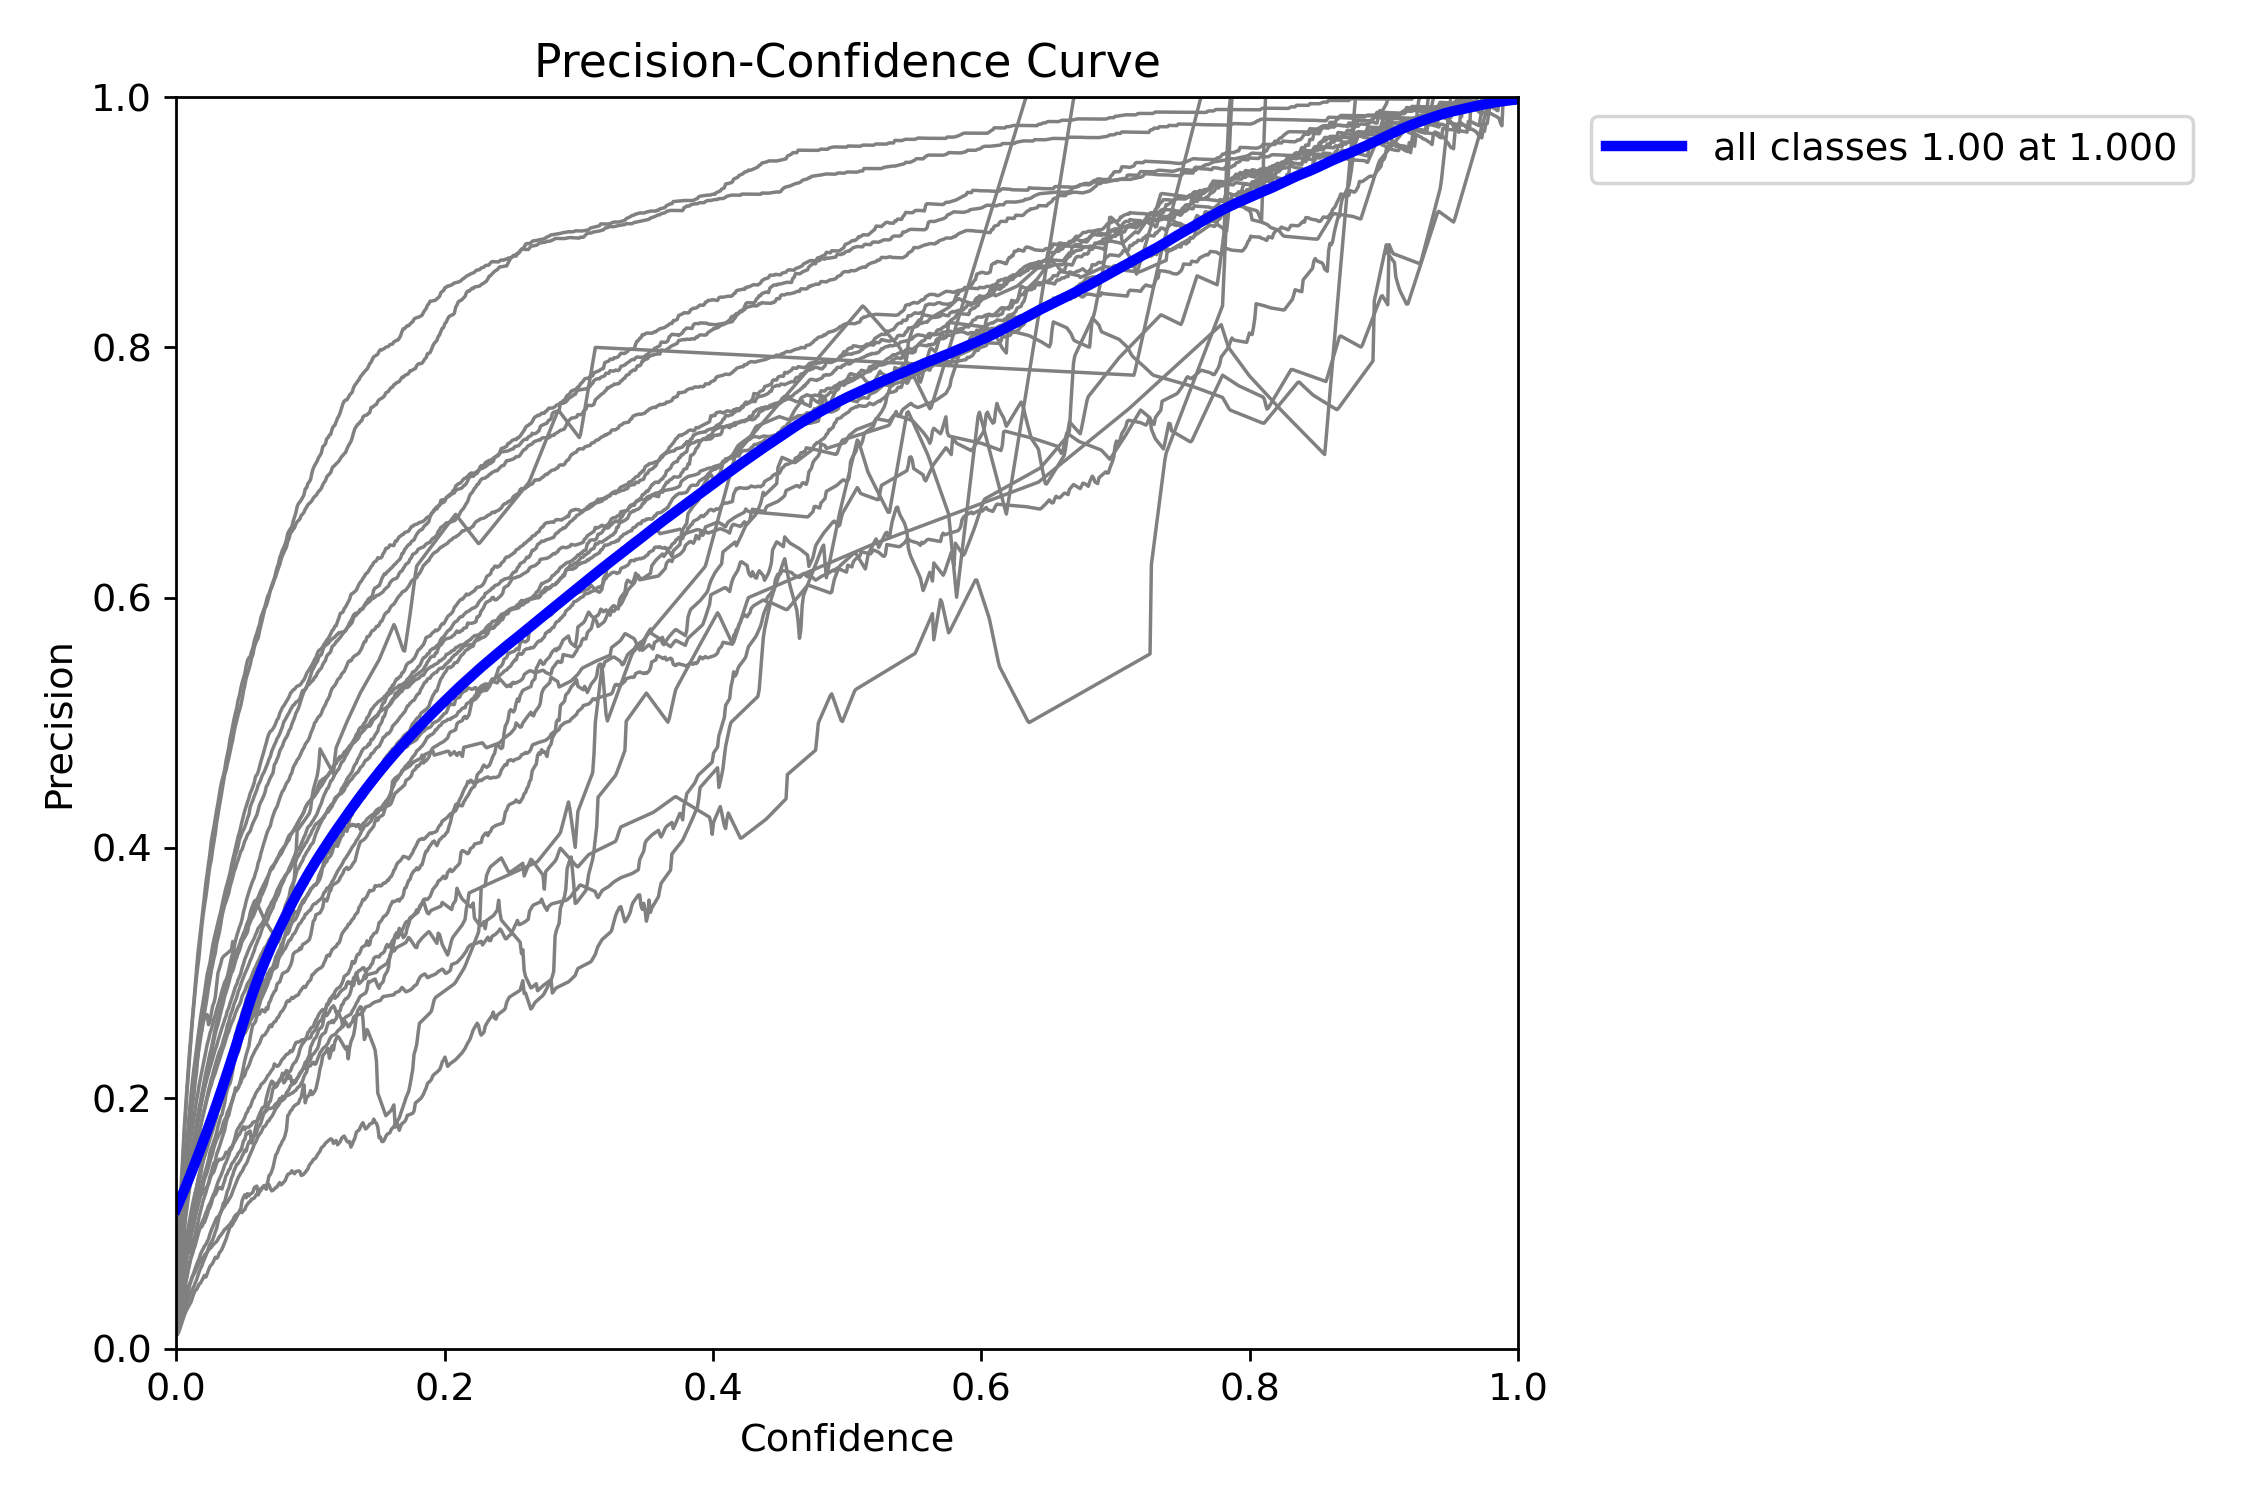

In [22]:
# Precision Curve
Image(filename=str(RESULTS_FOLDER/"BoxP_curve.png"))

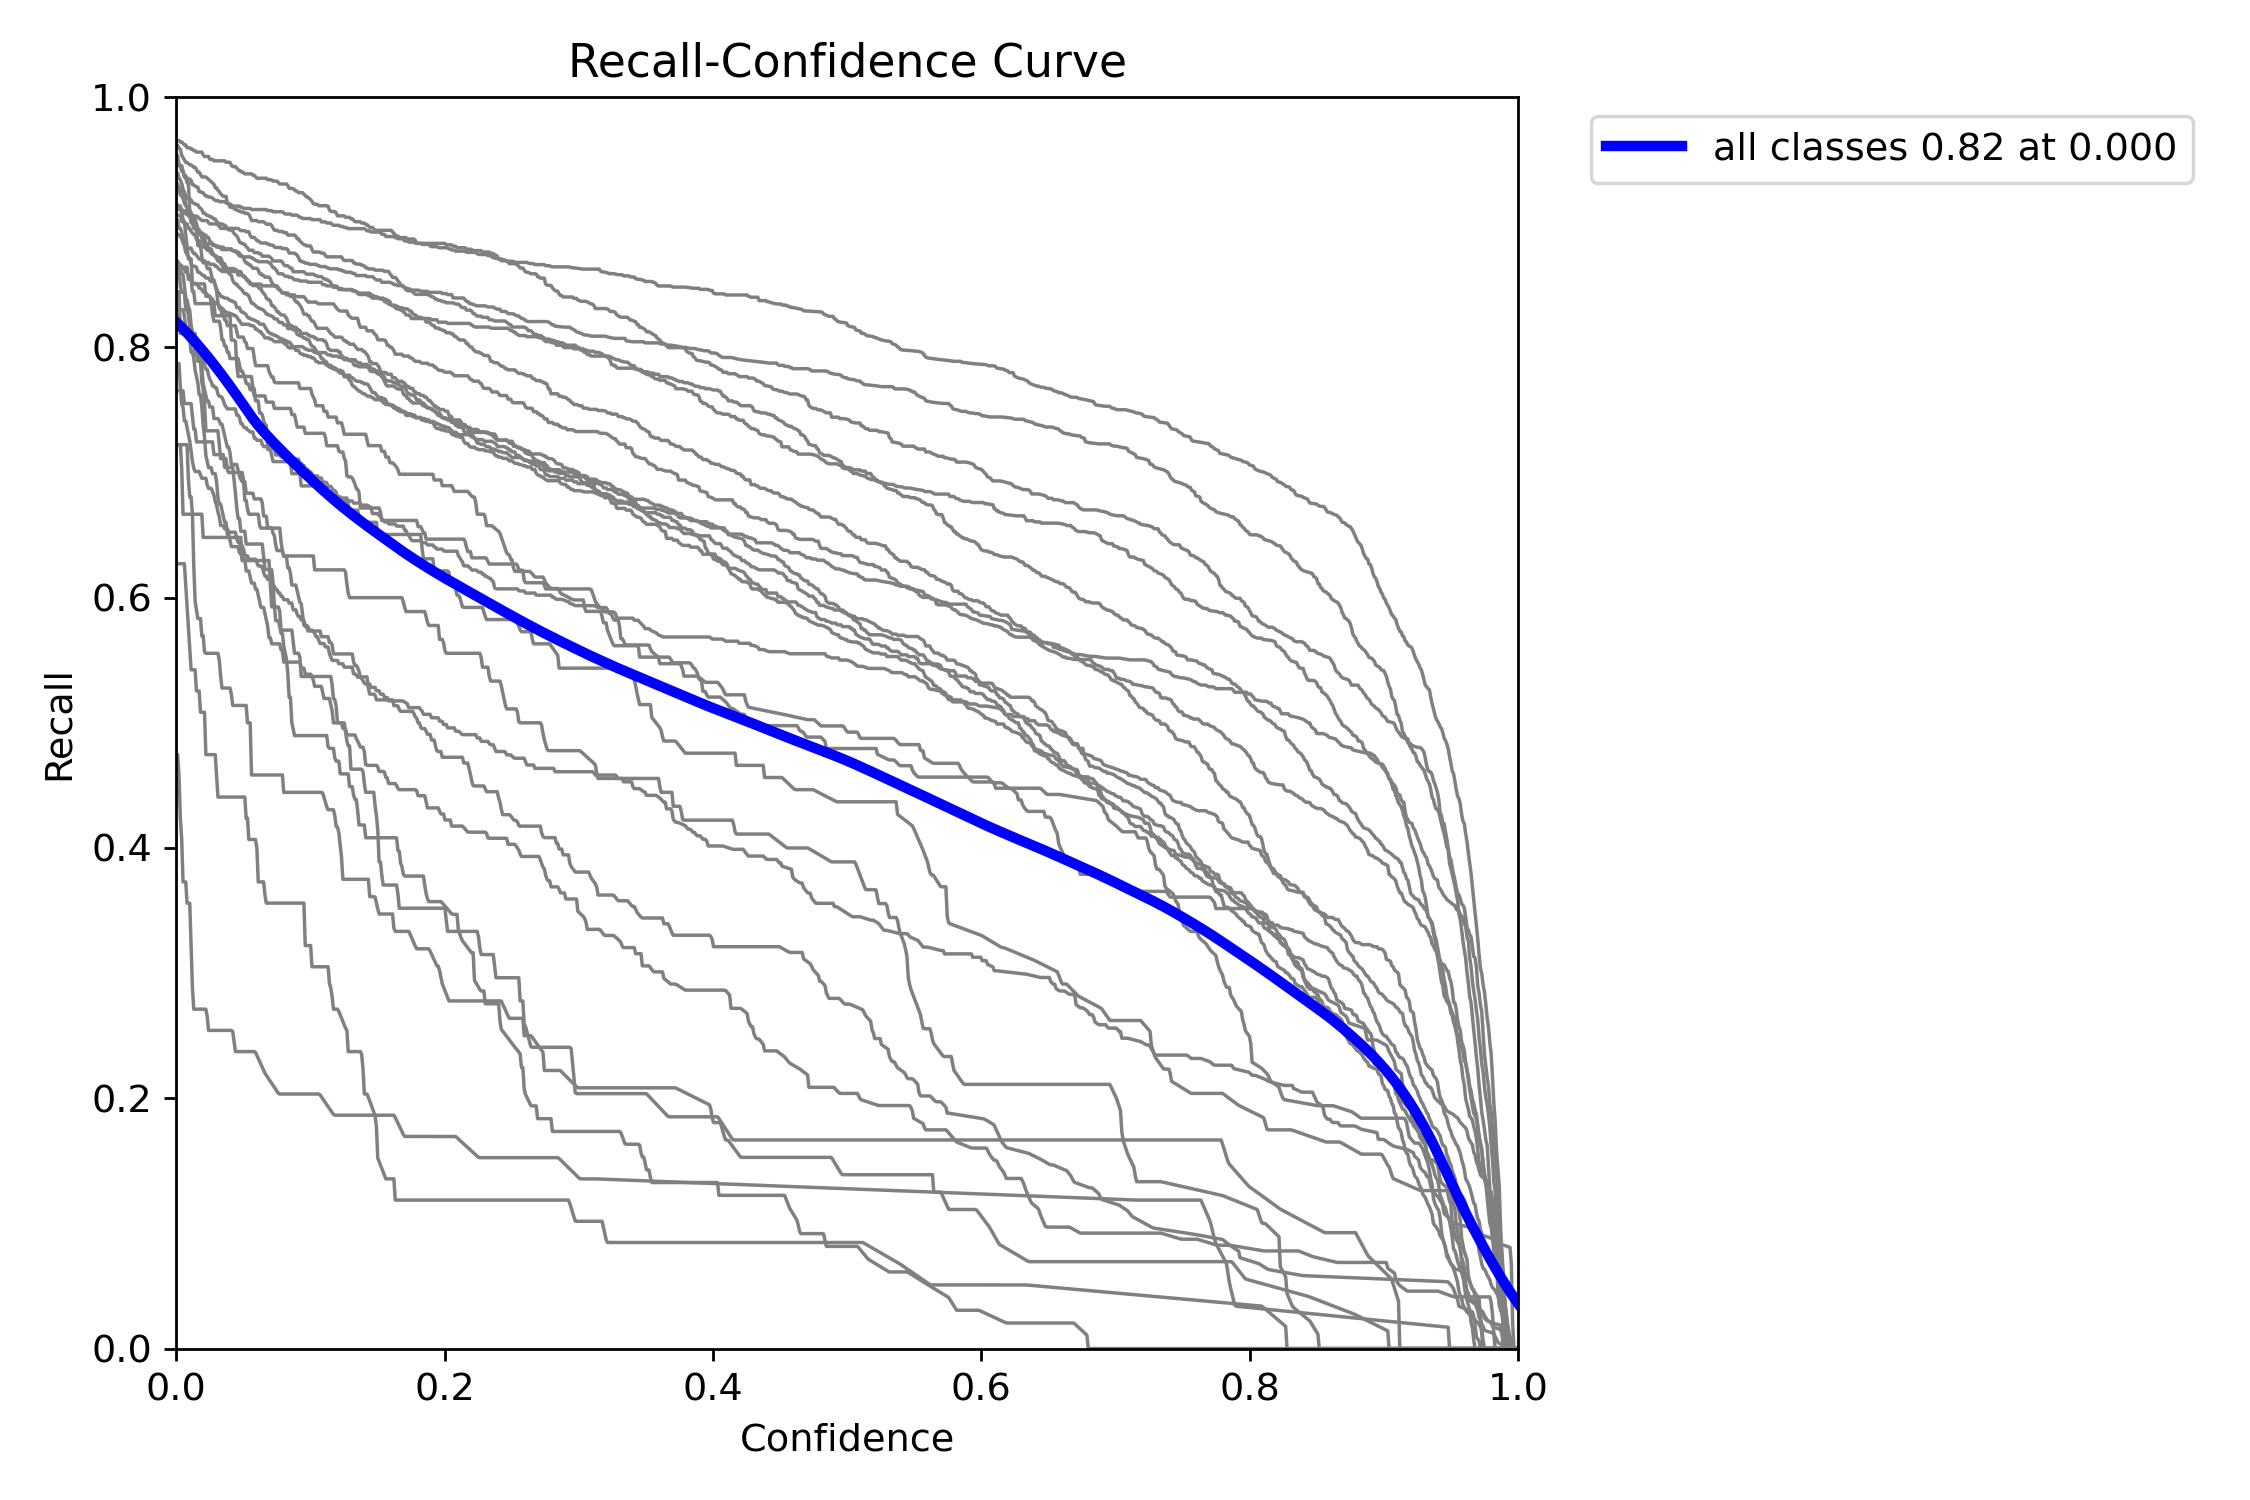

In [23]:
# Recall Curve
Image(filename=str(RESULTS_FOLDER/"BoxR_curve.png"))

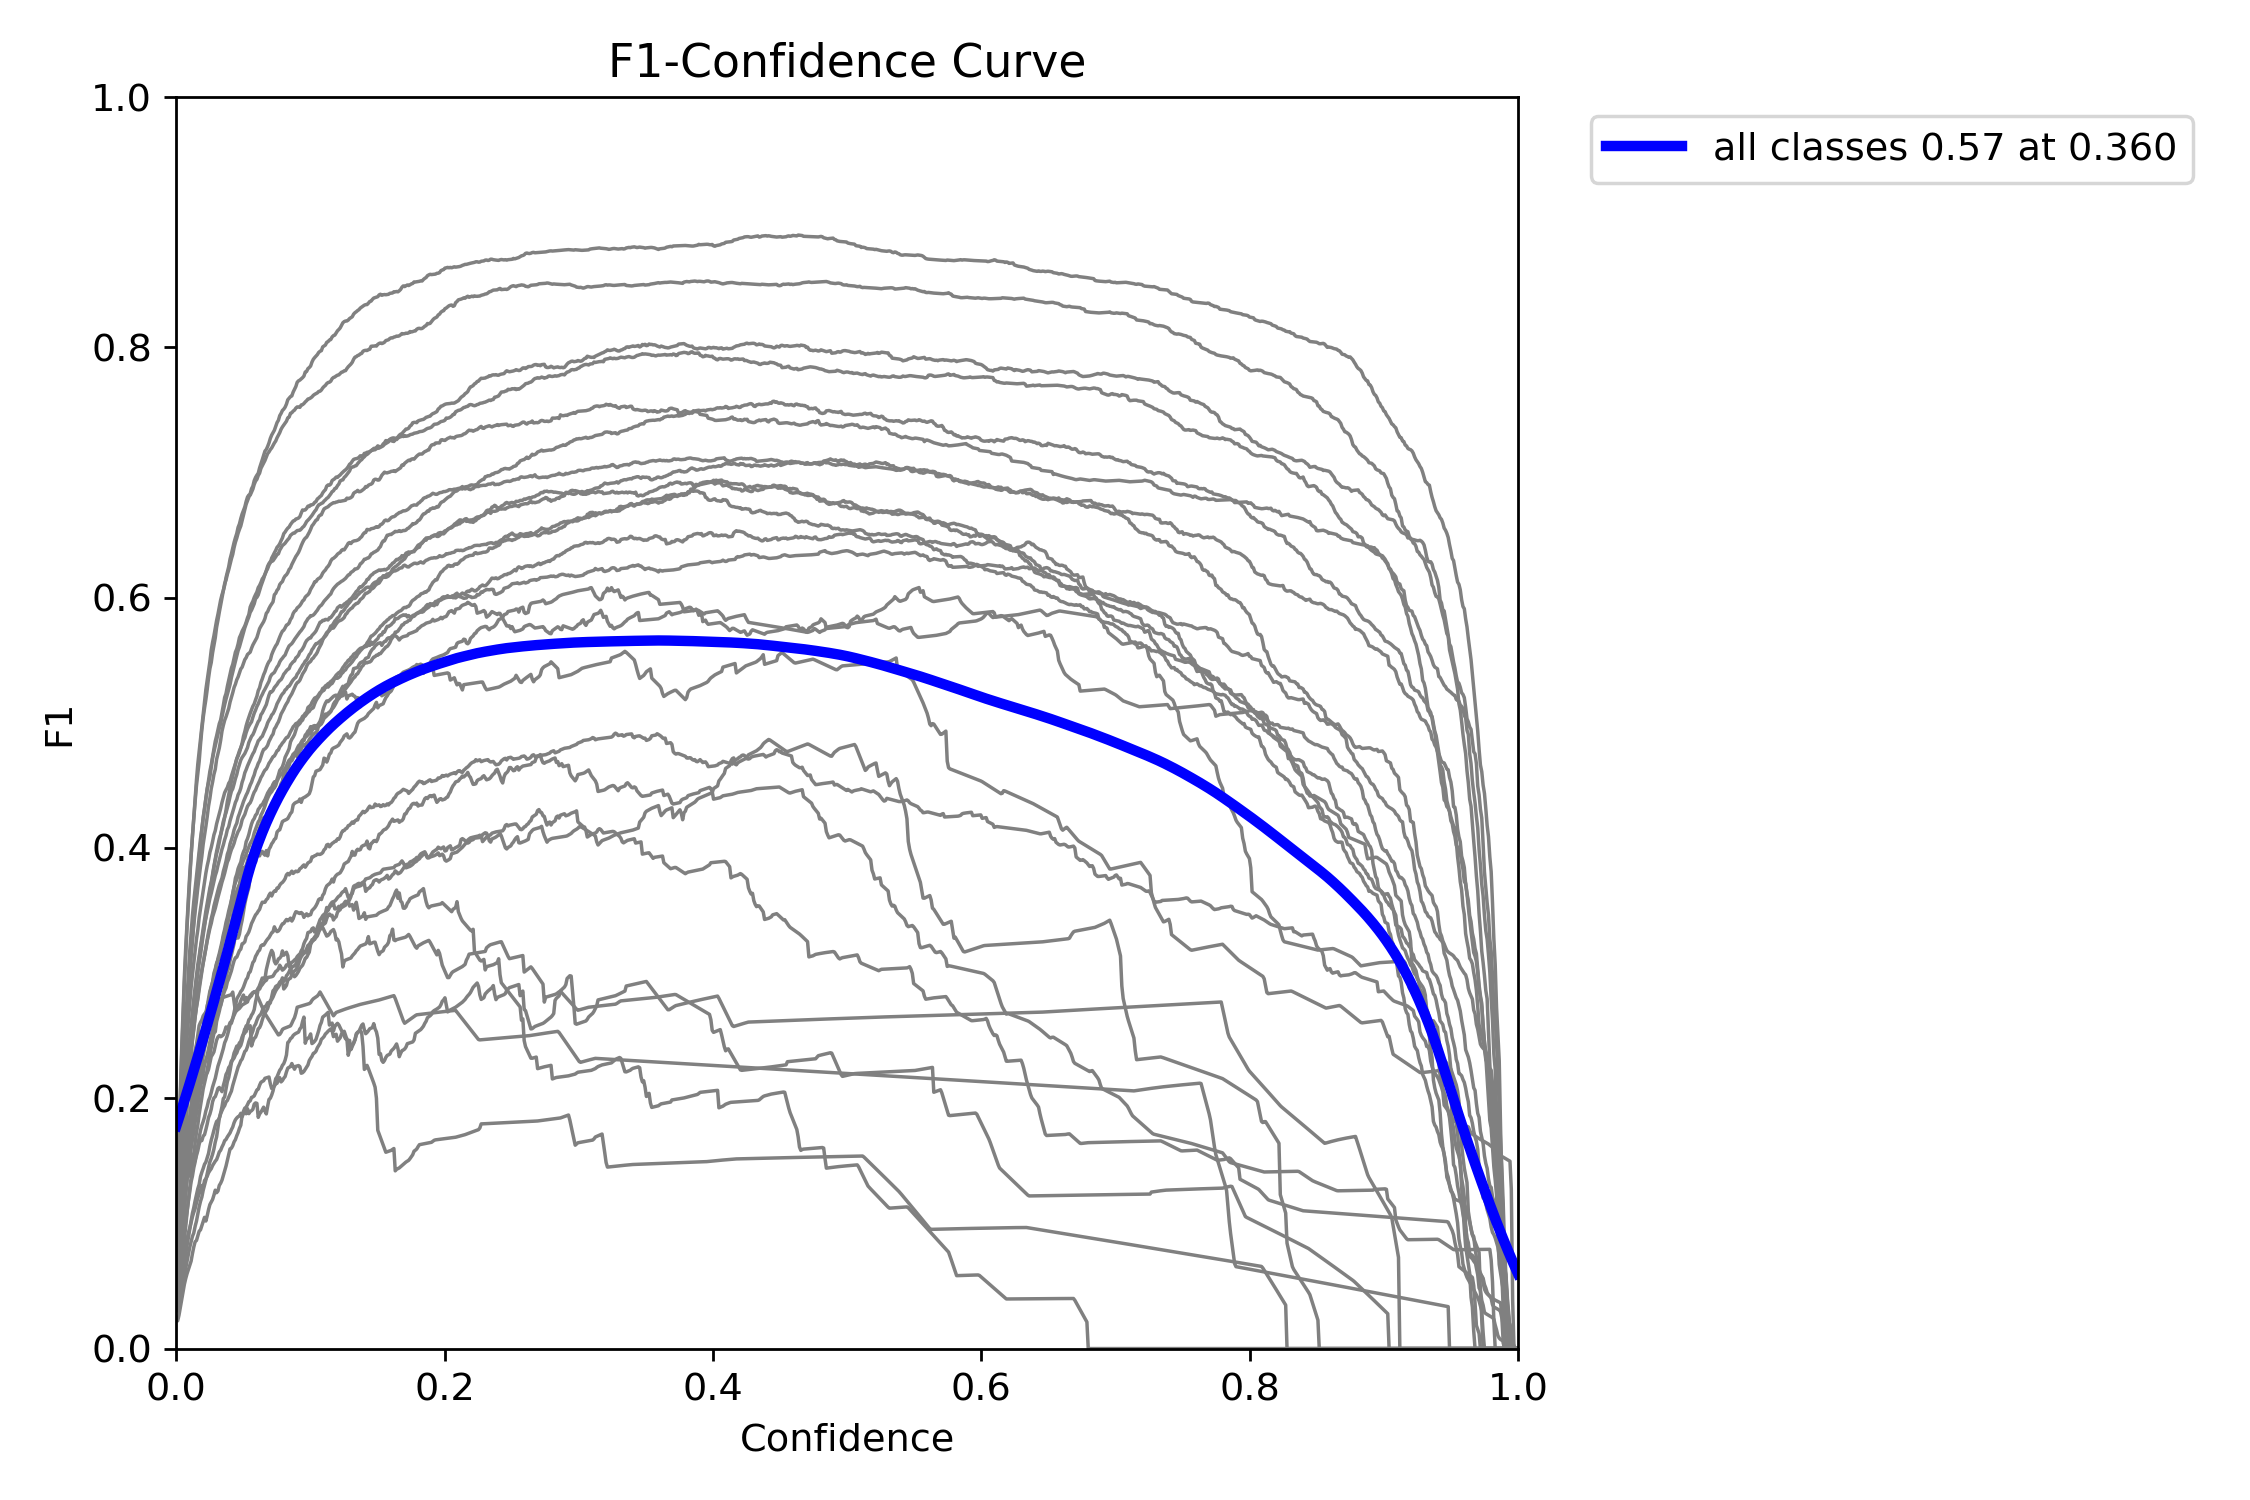

In [24]:
# F1 Curve
Image(filename=str(RESULTS_FOLDER/"BoxF1_curve.png"))

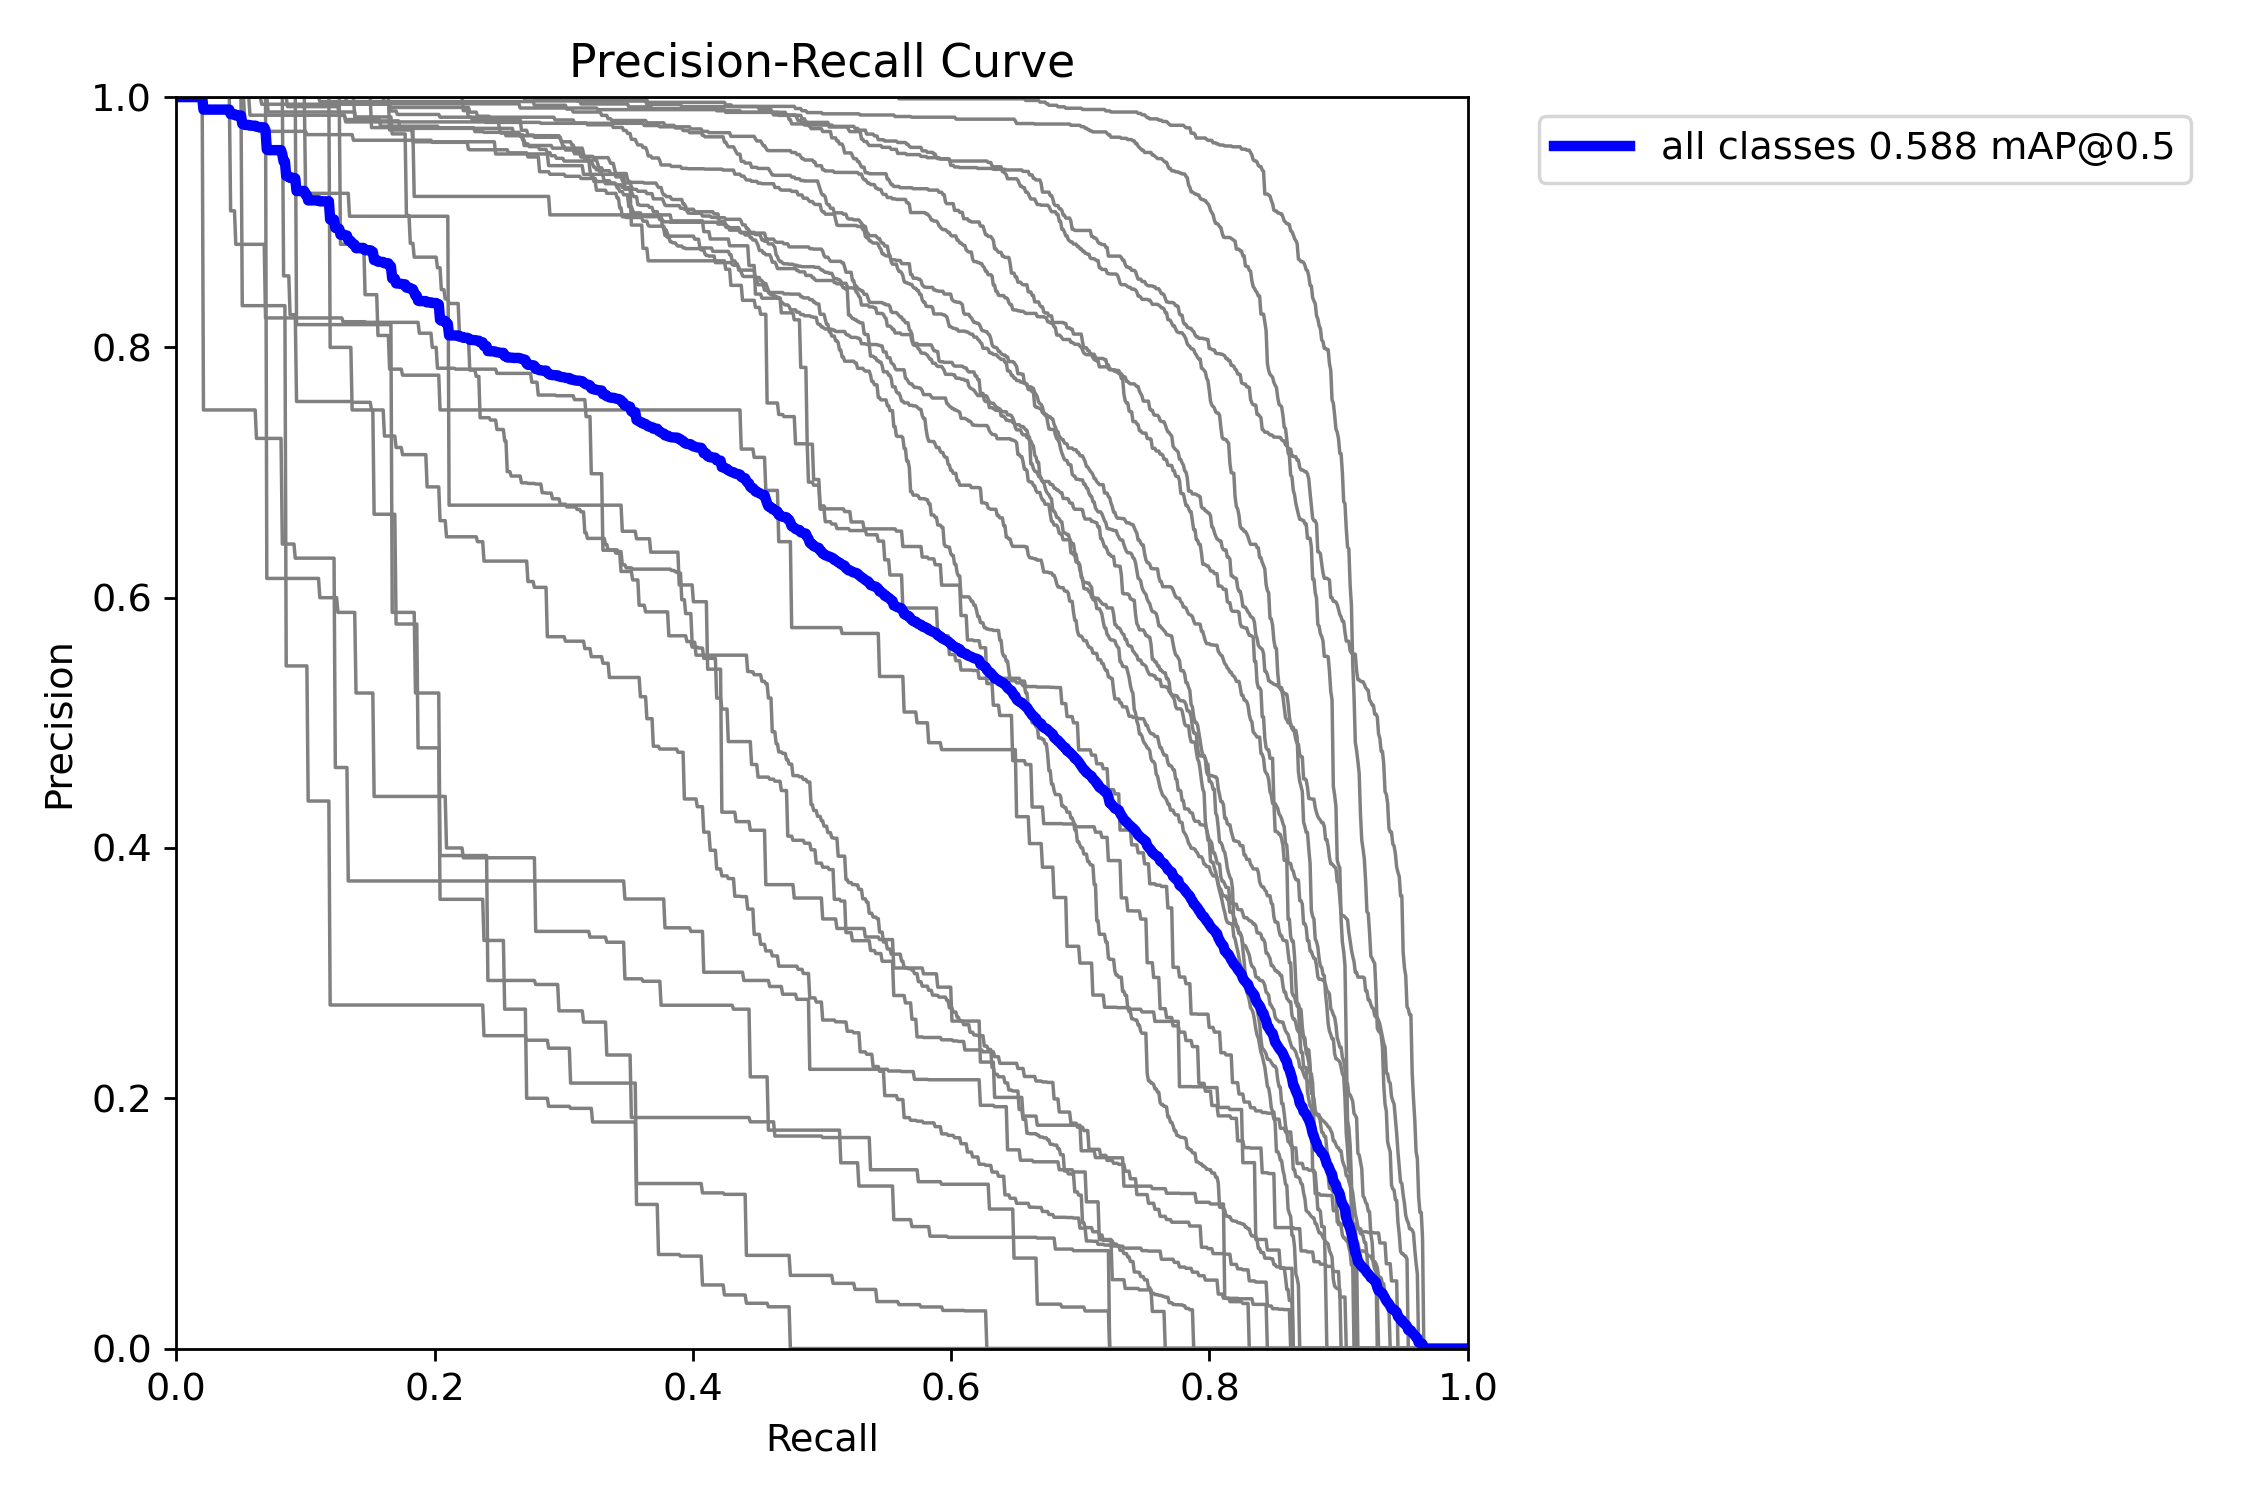

In [25]:
# PR Curve
Image(filename=str(RESULTS_FOLDER/"BoxPR_curve.png"))


In [26]:
# To display all at once
from IPython.display import Image, display

display(Image(filename=str(RESULTS_FOLDER/"confusion_matrix.png")))
display(Image(filename=str(RESULTS_FOLDER/"BoxP_curve.png")))
display(Image(filename=str(RESULTS_FOLDER/"BoxR_curve.png")))
display(Image(filename=str(RESULTS_FOLDER/"BoxF1_curve.png")))
display(Image(filename=str(RESULTS_FOLDER/"BoxPR_curve.png")))

Output hidden; open in https://colab.research.google.com to view.

In [27]:

# COMPLETE TRAINING HISTORY


pd.set_option("display.max_columns", None)

results_df

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,116.028,1.80318,4.15590,1.64622,0.40923,0.09010,0.05822,0.04040,1.52150,3.47907,1.41438,0.000115,0.000115,0.000115
1,2,223.877,1.33308,3.04524,1.32045,0.48059,0.16088,0.12052,0.08883,1.19933,2.70278,1.19230,0.000218,0.000218,0.000218
2,3,330.604,1.13204,2.49486,1.19903,0.44807,0.20330,0.18092,0.13623,1.08587,2.39151,1.11648,0.000310,0.000310,0.000310
3,4,439.956,1.01965,2.19722,1.12709,0.45151,0.26364,0.24971,0.18990,0.95995,2.03371,1.05146,0.000294,0.000294,0.000294
4,5,549.352,0.95855,2.01342,1.08919,0.45516,0.30018,0.29603,0.23447,0.84887,1.82592,0.99880,0.000277,0.000277,0.000277
5,6,656.787,0.89639,1.86590,1.05903,0.45464,0.35077,0.33010,0.25895,0.80667,1.70282,0.97848,0.000260,0.000260,0.000260
6,7,766.246,0.86359,1.76666,1.04232,0.48923,0.37143,0.36775,0.29552,0.76852,1.58142,0.95664,0.000243,0.000243,0.000243
7,8,873.812,0.83682,1.67973,1.02599,0.58532,0.37713,0.40809,0.32764,0.74088,1.46747,0.93828,0.000225,0.000225,0.000225
8,9,981.230,0.80934,1.60929,1.01540,0.51229,0.42079,0.42471,0.34390,0.71115,1.39259,0.92762,0.000208,0.000208,0.000208
9,10,1091.220,0.79656,1.56301,1.00725,0.54679,0.41810,0.43326,0.35376,0.68959,1.36109,0.91957,0.000191,0.000191,0.000191


In [30]:

# TRAINING SUMMARY


print("Total Epochs :", len(results_df))

print("Best mAP@0.5 :", results_df["metrics/mAP50(B)"].max())

print("Best Precision :", results_df["metrics/precision(B)"].max())

print("Best Recall :", results_df["metrics/recall(B)"].max())



Total Epochs : 20
Best mAP@0.5 : 0.58798
Best Precision : 0.65694
Best Recall : 0.53921


In [31]:

# SAVE EVALUATION REPORT


report_path = RESULTS_FOLDER / "evaluation_summary.txt"

with open(report_path, "w") as file:

    file.write("YOLO MODEL EVALUATION\n")
    file.write("="*50 + "\n\n")

    file.write(f"Best mAP@0.5 : {results_df['metrics/mAP50(B)'].max():.4f}\n")

    file.write(f"Best Precision : {results_df['metrics/precision(B)'].max():.4f}\n")

    file.write(f"Best Recall : {results_df['metrics/recall(B)'].max():.4f}\n")

print("Evaluation report saved successfully.")

Evaluation report saved successfully.


In [32]:
# GENERATED FILES


for file in sorted(RESULTS_FOLDER.iterdir()):

    print(file.name)

BoxF1_curve.png
BoxPR_curve.png
BoxP_curve.png
BoxR_curve.png
args.yaml
confusion_matrix.png
confusion_matrix_normalized.png
evaluation_summary.txt
labels.jpg
results.csv
results.png
train_batch0.jpg
train_batch1.jpg
train_batch2.jpg
train_batch2910.jpg
train_batch2911.jpg
train_batch2912.jpg
val_batch0_labels.jpg
val_batch0_pred.jpg
val_batch1_labels.jpg
val_batch1_pred.jpg
val_batch2_labels.jpg
val_batch2_pred.jpg
weights
